# Transistor Extraction Experiments

Notebook do eksperymentow z wycinaniem samego tranzystora z tla.
Cel: znalezc najbardziej stabilna metode foregroundu przed aktualizacja `model.py`.

In [3]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.titlesize'] = 10

In [4]:
def find_project_dir(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for c in candidates:
        if (c / 'transistor').exists() and (c / 'model.py').exists():
            return c
    raise FileNotFoundError('Nie znaleziono katalogu projektu (transistor + model.py).')

PROJECT_DIR = find_project_dir(Path.cwd())
DATA_DIR = PROJECT_DIR / 'transistor'
TEST_DIR = DATA_DIR / 'test'
GT_DIR = DATA_DIR / 'ground_truth'
TRAIN_GOOD_DIR = DATA_DIR / 'train' / 'good'

CLASSES = ['good', 'bent_lead', 'cut_lead', 'damaged_case', 'misplaced']
print('PROJECT_DIR:', PROJECT_DIR)

PROJECT_DIR: C:\Coding\Sem_6\ZAW\CWP\Transformers\proj01


In [5]:
def load_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def iter_test():
    for cls_name in CLASSES:
        for p in sorted((TEST_DIR / cls_name).glob('*.png')):
            yield cls_name, p

def overlap_with_misplaced_gt(mask: np.ndarray, img_path: Path) -> float:
    gt_path = GT_DIR / 'misplaced' / f"{img_path.stem}_mask.png"
    gt = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
    if gt is None:
        return np.nan
    m = mask > 0
    g = gt > 0
    union = np.logical_or(m, g).sum()
    if union == 0:
        return 1.0
    inter = np.logical_and(m, g).sum()
    return float(inter / union)

def component_cleanup(mask: np.ndarray, min_area: int = 30) -> np.ndarray:
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    out = np.zeros_like(mask)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            out[labels == i] = 255
    return out

def border_leak_ratio(mask: np.ndarray) -> float:
    h, w = mask.shape
    border = np.zeros_like(mask, dtype=bool)
    border[0, :] = True
    border[-1, :] = True
    border[:, 0] = True
    border[:, -1] = True
    selected = mask > 0
    if selected.sum() == 0:
        return 0.0
    return float(np.logical_and(selected, border).sum() / selected.sum())

In [6]:
# Metoda A: Otsu + morfologia
def fg_otsu(gray: np.ndarray) -> np.ndarray:
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, m = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=1)
    return component_cleanup(m, min_area=40)

# Metoda B: HSV low-sat + dark
def fg_hsv(img_rgb: np.ndarray) -> np.ndarray:
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]
    m = ((s < 85) & (v < 210)).astype(np.uint8) * 255
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=1)
    return component_cleanup(m, min_area=40)

def remove_border_stripes(mask: np.ndarray) -> np.ndarray:
    """Usuwa komponenty tla: pionowe pasy przy krawedziach i male obiekty."""
    h, w = mask.shape
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    out = np.zeros_like(mask)

    for i in range(1, n):
        x = int(stats[i, cv2.CC_STAT_LEFT])
        y = int(stats[i, cv2.CC_STAT_TOP])
        cw = int(stats[i, cv2.CC_STAT_WIDTH])
        ch = int(stats[i, cv2.CC_STAT_HEIGHT])
        area = int(stats[i, cv2.CC_STAT_AREA])

        if area < 40:
            continue

        touches_border = x <= 1 or y <= 1 or (x + cw) >= (w - 1) or (y + ch) >= (h - 1)
        aspect = max(cw, ch) / float(min(cw, ch) + 1e-6)
        long_vertical = ch >= int(0.65 * h) and cw <= int(0.08 * w)

        if touches_border and long_vertical and aspect > 6.0:
            continue

        out[labels == i] = 255

    return out

def fill_wire_holes(mask: np.ndarray) -> np.ndarray:
    """Domyka czarne dziury wewnatrz bialych przewodow tranzystora."""
    m = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=1)

    # Fill only inner holes.
    ff = m.copy()
    h, w = ff.shape
    flood_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)
    cv2.floodFill(ff, flood_mask, (0, 0), 255)
    holes = cv2.bitwise_not(ff)
    filled = cv2.bitwise_or(m, holes)
    return filled

def extract_main_component(mask: np.ndarray) -> np.ndarray:
    """Zostawia glowny komponent tranzystora (duzy i blisko srodka)."""
    h, w = mask.shape
    n, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, 8)
    if n <= 1:
        return np.zeros_like(mask)

    best_idx = None
    best_score = -1.0
    for i in range(1, n):
        area = float(stats[i, cv2.CC_STAT_AREA])
        if area < 800:
            continue
        cx, cy = centroids[i]
        center_pen = abs(cx - 0.5 * w) / w + abs(cy - 0.45 * h) / h
        score = area * (1.2 - center_pen)
        if score > best_score:
            best_score = score
            best_idx = i

    out = np.zeros_like(mask)
    if best_idx is not None:
        out[labels == best_idx] = 255
    return out

VOTE_MASK = None

def get_vote_mask() -> np.ndarray:
    """Buduje maske konsensusu tranzystora z train/good."""
    global VOTE_MASK
    if VOTE_MASK is not None:
        return VOTE_MASK

    files = sorted(TRAIN_GOOD_DIR.glob('*.png'))
    if not files:
        # Bez train/good zwracamy pelna maske (brak ograniczenia ROI).
        VOTE_MASK = np.ones((1024, 1024), dtype=np.uint8) * 255
        return VOTE_MASK

    acc = None
    count = 0
    for p in files:
        img = load_rgb(p)
        m = fg_hsv(img)
        m = remove_border_stripes(m)
        m = extract_main_component(m)
        if acc is None:
            acc = np.zeros_like(m, dtype=np.float32)
        acc += (m > 0).astype(np.float32)
        count += 1

    vote = acc / max(count, 1)
    roi = (vote >= 0.65).astype(np.uint8) * 255
    roi = cv2.morphologyEx(roi, cv2.MORPH_CLOSE, np.ones((11, 11), np.uint8), iterations=1)
    roi = cv2.dilate(roi, np.ones((9, 9), np.uint8), iterations=1)
    VOTE_MASK = roi.astype(np.uint8)
    return VOTE_MASK

# Metoda C: Otsu AND HSV
def fg_hybrid(img_rgb: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    m1 = fg_otsu(gray)
    m2 = fg_hsv(img_rgb)
    m = cv2.bitwise_and(m1, m2)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8), iterations=1)
    return component_cleanup(m, min_area=60)

# Metoda D: HSV + filtr pasow tla + wypelnianie drutow
def fg_hsv_refined(img_rgb: np.ndarray) -> np.ndarray:
    m = fg_hsv(img_rgb)
    m = remove_border_stripes(m)
    m = fill_wire_holes(m)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    return component_cleanup(m, min_area=60)

# Metoda E: Refined + maska konsensusu z train/good
def fg_hsv_vote(img_rgb: np.ndarray) -> np.ndarray:
    m = fg_hsv_refined(img_rgb)
    roi = get_vote_mask()
    m = cv2.bitwise_and(m, roi)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=1)
    return component_cleanup(m, min_area=80)

METHODS = {
    'hsv_refined': fg_hsv_refined,
}

In [7]:
# Dodatkowa metoda: miekka wersja vote-mask
def fg_hsv_vote_soft(img_rgb: np.ndarray) -> np.ndarray:
    base = fg_hsv_refined(img_rgb)
    roi_hard = get_vote_mask()

    # Soft ROI: wiekszy margines, mniej agresywne przycinanie obiektu.
    roi_soft = cv2.dilate(roi_hard, np.ones((25, 25), np.uint8), iterations=1)

    h, w = base.shape
    keep_legs = np.zeros_like(base)
    keep_legs[int(0.55 * h):, :] = 255

    # Zachowujemy piksele z soft ROI oraz dolna strefe (nogi tranzystora).
    allowed = cv2.bitwise_or(roi_soft, keep_legs)
    m = cv2.bitwise_and(base, allowed)

    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=1)
    return component_cleanup(m, min_area=60)

METHODS['hsv_vote_soft'] = fg_hsv_vote_soft

In [7]:
# Eksperyment: usuwanie malych kol tla (dot suppression)
def suppress_background_dots(mask: np.ndarray) -> np.ndarray:
    """
    Usuwa male, okragle komponenty tla (kropki planszy) poza glownym obiektem tranzystora.
    """
    h, w = mask.shape
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if n <= 1:
        return mask

    # Najwiekszy komponent traktujemy jako glowny obiekt tranzystora.
    main_idx = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    main_x = int(stats[main_idx, cv2.CC_STAT_LEFT])
    main_y = int(stats[main_idx, cv2.CC_STAT_TOP])
    main_w = int(stats[main_idx, cv2.CC_STAT_WIDTH])
    main_h = int(stats[main_idx, cv2.CC_STAT_HEIGHT])

    # Lekko rozszerzony bbox glównego obiektu - wszystko daleko poza nim to kandydaci na kropki.
    margin_x = int(0.06 * w)
    margin_y = int(0.06 * h)
    bx0 = max(0, main_x - margin_x)
    by0 = max(0, main_y - margin_y)
    bx1 = min(w - 1, main_x + main_w + margin_x)
    by1 = min(h - 1, main_y + main_h + margin_y)

    out = np.zeros_like(mask)
    out[labels == main_idx] = 255

    for i in range(1, n):
        if i == main_idx:
            continue

        x = int(stats[i, cv2.CC_STAT_LEFT])
        y = int(stats[i, cv2.CC_STAT_TOP])
        cw = int(stats[i, cv2.CC_STAT_WIDTH])
        ch = int(stats[i, cv2.CC_STAT_HEIGHT])
        area = float(stats[i, cv2.CC_STAT_AREA])

        # Punkty i drobny szum i tak odrzucamy.
        if area < 40:
            continue

        # Przyblizona kolowosc z bboxu - kropki maja zwykle zblizone wymiary x/y.
        ratio = min(cw, ch) / float(max(cw, ch) + 1e-6)
        inside_expanded_bbox = not (x + cw < bx0 or x > bx1 or y + ch < by0 or y > by1)

        # Heurystyka kropek tla: male + prawie okragle + poza glownym obiektem.
        is_dot = (80 <= area <= 3500) and (ratio >= 0.65) and (not inside_expanded_bbox)
        if is_dot:
            continue

        out[labels == i] = 255

    out = cv2.morphologyEx(out, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=1)
    return out

def fg_hsv_refined_nodots(img_rgb: np.ndarray) -> np.ndarray:
    m = fg_hsv_refined(img_rgb)
    m = suppress_background_dots(m)
    return component_cleanup(m, min_area=60)

def fg_hsv_vote_soft_nodots(img_rgb: np.ndarray) -> np.ndarray:
    m = fg_hsv_vote_soft(img_rgb)
    m = suppress_background_dots(m)
    return component_cleanup(m, min_area=60)

METHODS['hsv_refined_nodots'] = fg_hsv_refined_nodots
METHODS['hsv_vote_soft_nodots'] = fg_hsv_vote_soft_nodots

In [8]:
# Eksperyment: usuwanie kropek przez wspolczynniki ksztaltu
def suppress_circular_components(mask: np.ndarray) -> np.ndarray:
    """
    Usuwa male, okragle komponenty tla na podstawie cech ksztaltu.
    """
    m = (mask > 0).astype(np.uint8) * 255
    n, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if n <= 1:
        return m

    # Glowny obiekt (tranzystor) zachowujemy zawsze.
    main_idx = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    out = np.zeros_like(m)
    out[labels == main_idx] = 255

    h, w = m.shape
    main_x = int(stats[main_idx, cv2.CC_STAT_LEFT])
    main_y = int(stats[main_idx, cv2.CC_STAT_TOP])
    main_w = int(stats[main_idx, cv2.CC_STAT_WIDTH])
    main_h = int(stats[main_idx, cv2.CC_STAT_HEIGHT])
    pad_x = int(0.08 * w)
    pad_y = int(0.08 * h)
    bx0 = max(0, main_x - pad_x)
    by0 = max(0, main_y - pad_y)
    bx1 = min(w - 1, main_x + main_w + pad_x)
    by1 = min(h - 1, main_y + main_h + pad_y)

    for i in range(1, n):
        if i == main_idx:
            continue

        x = int(stats[i, cv2.CC_STAT_LEFT])
        y = int(stats[i, cv2.CC_STAT_TOP])
        cw = int(stats[i, cv2.CC_STAT_WIDTH])
        ch = int(stats[i, cv2.CC_STAT_HEIGHT])
        area = float(stats[i, cv2.CC_STAT_AREA])

        # Szybki odrzut bardzo malego szumu.
        if area < 25:
            continue

        comp = np.zeros_like(m)
        comp[labels == i] = 255
        cnts, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            continue

        cnt = max(cnts, key=cv2.contourArea)
        perim = cv2.arcLength(cnt, True)
        if perim < 1e-6:
            continue

        contour_area = float(cv2.contourArea(cnt))
        circularity = (4.0 * np.pi * contour_area) / (perim * perim + 1e-6)
        aspect = min(cw, ch) / float(max(cw, ch) + 1e-6)
        extent = contour_area / float(cw * ch + 1e-6)

        # Czy komponent styka sie z rozszerzonym bbox tranzystora?
        near_main = not (x + cw < bx0 or x > bx1 or y + ch < by0 or y > by1)

        # Heurystyka kropek: male, prawie kolowe i poza obiektem tranzystora.
        is_dot = (60 <= area <= 2600) and (circularity >= 0.55) and (aspect >= 0.72) and (extent >= 0.55) and (not near_main)
        if is_dot:
            continue

        out[labels == i] = 255

    out = cv2.morphologyEx(out, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=1)
    return out

def fg_hsv_refined_shape(img_rgb: np.ndarray) -> np.ndarray:
    m = fg_hsv_refined(img_rgb)
    m = suppress_circular_components(m)
    return component_cleanup(m, min_area=60)

def fg_hsv_vote_soft_shape(img_rgb: np.ndarray) -> np.ndarray:
    m = fg_hsv_vote_soft(img_rgb)
    m = suppress_circular_components(m)
    return component_cleanup(m, min_area=60)

METHODS['hsv_refined_shape'] = fg_hsv_refined_shape
METHODS['hsv_vote_soft_shape'] = fg_hsv_vote_soft_shape

In [10]:
def suppress_circular_components_param(mask: np.ndarray, params: dict) -> np.ndarray:
    """Usuwa male, kolowe komponenty tla wg parametrow z DOT_PARAMS."""
    m = (mask > 0).astype(np.uint8) * 255
    n, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if n <= 1:
        return m

    h, w = m.shape
    main_idx = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    out = np.zeros_like(m)
    out[labels == main_idx] = 255

    main_x = int(stats[main_idx, cv2.CC_STAT_LEFT])
    main_y = int(stats[main_idx, cv2.CC_STAT_TOP])
    main_w = int(stats[main_idx, cv2.CC_STAT_WIDTH])
    main_h = int(stats[main_idx, cv2.CC_STAT_HEIGHT])
    pad_x = int(params['pad_x_ratio'] * w)
    pad_y = int(params['pad_y_ratio'] * h)
    bx0 = max(0, main_x - pad_x)
    by0 = max(0, main_y - pad_y)
    bx1 = min(w - 1, main_x + main_w + pad_x)
    by1 = min(h - 1, main_y + main_h + pad_y)

    for i in range(1, n):
        if i == main_idx:
            continue

        x = int(stats[i, cv2.CC_STAT_LEFT])
        y = int(stats[i, cv2.CC_STAT_TOP])
        cw = int(stats[i, cv2.CC_STAT_WIDTH])
        ch = int(stats[i, cv2.CC_STAT_HEIGHT])
        area = float(stats[i, cv2.CC_STAT_AREA])

        if area < 25:
            continue

        comp = np.zeros_like(m)
        comp[labels == i] = 255
        cnts, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            continue
        cnt = max(cnts, key=cv2.contourArea)

        perim = cv2.arcLength(cnt, True)
        if perim < 1e-6:
            continue

        contour_area = float(cv2.contourArea(cnt))
        circularity = (4.0 * np.pi * contour_area) / (perim * perim + 1e-6)
        aspect = min(cw, ch) / float(max(cw, ch) + 1e-6)
        extent = contour_area / float(cw * ch + 1e-6)

        near_main = not (x + cw < bx0 or x > bx1 or y + ch < by0 or y > by1)

        is_dot = (
            (params['area_min'] <= area <= params['area_max'])
            and (circularity >= params['circularity_min'])
            and (aspect >= params['aspect_min'])
            and (extent >= params['extent_min'])
            and (not near_main)
        )
        if is_dot:
            continue

        out[labels == i] = 255

    k = int(max(1, params['final_close_kernel']))
    kernel = np.ones((k, k), np.uint8)
    out = cv2.morphologyEx(out, cv2.MORPH_CLOSE, kernel, iterations=1)
    out = component_cleanup(out, min_area=int(params['final_min_area']))
    return out

def make_tuned_method(base_name: str, params: dict):
    """Buduje funkcje: metoda bazowa + strojony filtr kropek."""
    base_map = {
        'hsv_refined': fg_hsv_refined,
        'hsv_vote_soft': fg_hsv_vote_soft,
    }
    if base_name not in base_map:
        raise ValueError(f'Nieznana metoda bazowa: {base_name}')

    base_fn = base_map[base_name]

    def tuned_fn(img_rgb: np.ndarray) -> np.ndarray:
        base_mask = base_fn(img_rgb)
        return suppress_circular_components_param(base_mask, params)

    return tuned_fn

def preview_tuned_method(tuned_fn, title: str = 'tuned') -> None:
    """Szybki podglad na 4 obrazach: good/cut_lead/damaged_case/misplaced."""
    sample_plan = [('good', 0), ('cut_lead', 0), ('damaged_case', 0), ('misplaced', 0)]
    rows = len(sample_plan)
    fig, axes = plt.subplots(rows, 3, figsize=(12, 3.2 * rows))

    for r, (cls_name, idx) in enumerate(sample_plan):
        files = sorted((TEST_DIR / cls_name).glob('*.png'))
        if not files:
            continue
        p = files[min(idx, len(files) - 1)]
        img = load_rgb(p)
        m = tuned_fn(img)

        axes[r, 0].imshow(img)
        axes[r, 0].set_title(f'Input: {cls_name} / {p.name}')
        axes[r, 0].axis('off')

        axes[r, 1].imshow(m, cmap='gray', vmin=0, vmax=255)
        axes[r, 1].set_title(title)
        axes[r, 1].axis('off')

        # Podglad samych usunietych pikseli (co filtr wycial).
        base = (fg_hsv_refined(img) if TUNE_BASE_METHOD == 'hsv_refined' else fg_hsv_vote_soft(img))
        removed = cv2.bitwise_and(base, cv2.bitwise_not(m))
        axes[r, 2].imshow(removed, cmap='magma')
        axes[r, 2].set_title('usuniete przez filtr')
        axes[r, 2].axis('off')

    plt.tight_layout()
    plt.show()

def evaluate_tuned_method_full(tuned_fn) -> None:
    """Pelna ocena na test secie (te same proxy metryki co w notebooku)."""
    stats = {'area': [], 'border_leak': [], 'misplaced_iou': []}
    for cls_name, p in iter_test():
        img = load_rgb(p)
        m = tuned_fn(img)
        stats['area'].append(float((m > 0).mean()))
        stats['border_leak'].append(border_leak_ratio(m))
        if cls_name == 'misplaced':
            stats['misplaced_iou'].append(overlap_with_misplaced_gt(m, p))

    area = np.array(stats['area'], dtype=np.float32)
    leak = np.array(stats['border_leak'], dtype=np.float32)
    miou = np.array(stats['misplaced_iou'], dtype=np.float32)
    print('=== Tuned Method Summary ===')
    print(f"area_mean={area.mean():.4f}")
    print(f"border_leak_mean={leak.mean():.4f}")
    print(f"misplaced_iou_mean={np.nanmean(miou):.4f}")

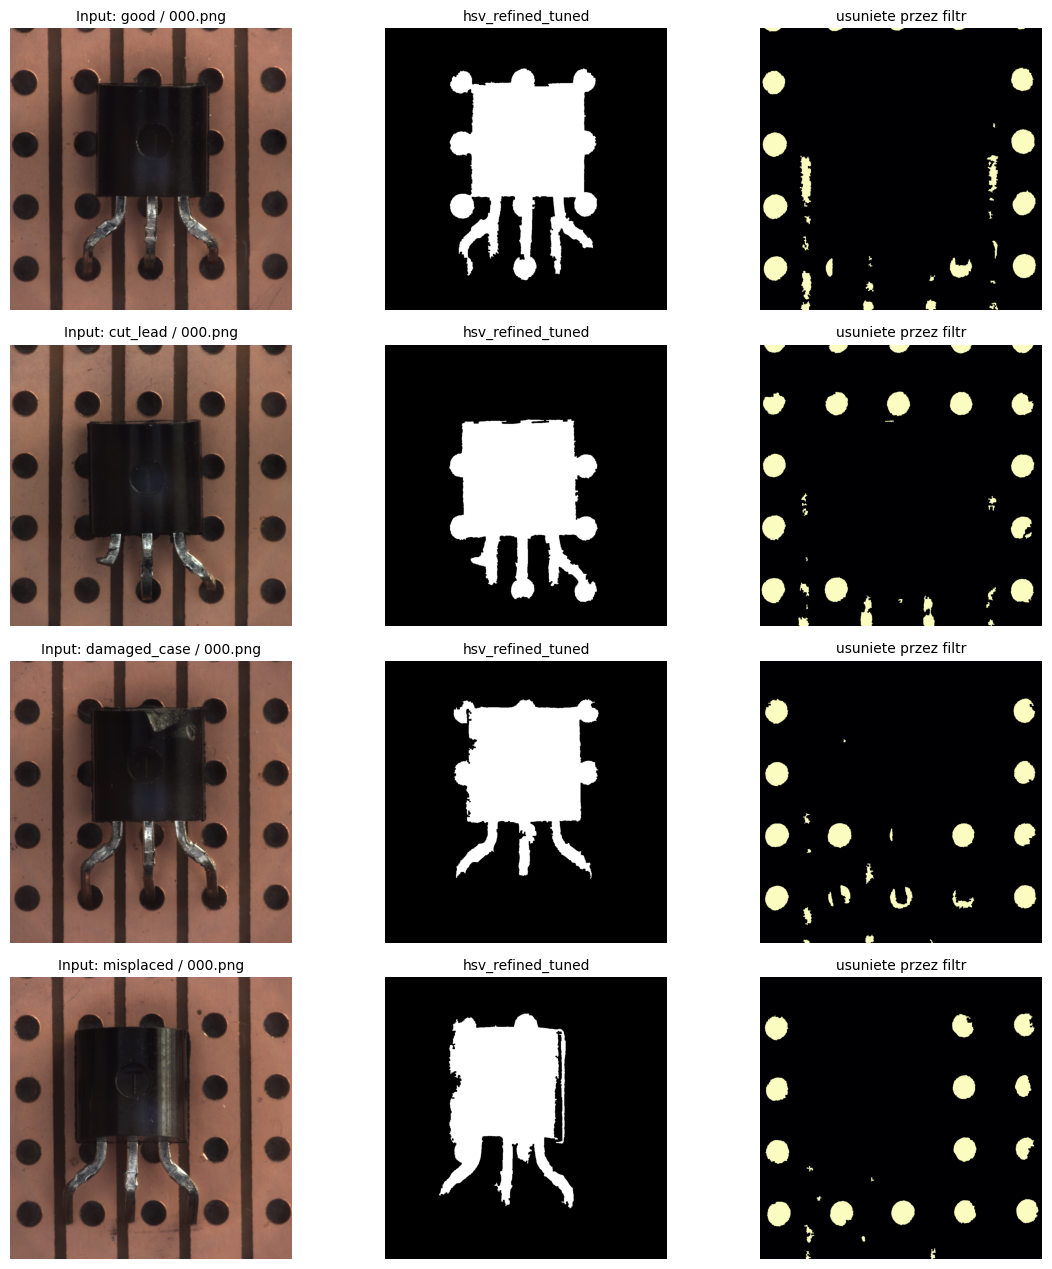

Pelna ewaluacja wylaczona. Ustaw RUN_FULL_DATASET=True, aby policzyc metryki na calym test secie.


In [11]:
# ====== Playground: strojenie filtrowania kropek tla ======
# W tej komorce zmieniasz parametry i od razu widzisz efekt.

DOT_PARAMS = {
    # Minimalna i maksymalna powierzchnia komponentu (w pikselach).
    # Typowe kropki planszy wpadaja w ten zakres.
    'area_min': 10,
    'area_max': 6000,

    # Kolistosc: 1.0 = idealne kolo.
    # Wzor: 4*pi*Area / Perimeter^2
    'circularity_min': 0.3,

    # Proporcja bokow bbox: min(w,h)/max(w,h).
    # Im blizej 1.0, tym komponent bardziej "okragly/kwadratowy".
    'aspect_min': 0.10,

    # Extent: contour_area / (bbox_w*bbox_h).
    # Niskie wartosci zwykle oznaczaja cienkie/poszarpane obiekty.
    'extent_min': 0.35,

    # Margines wokol glownego komponentu (tranzystora).
    # Kropki blisko tranzystora zwykle zachowujemy, by nie ucinać nozek.
    'pad_x_ratio': 0.001,
    'pad_y_ratio': 0.001,

    # Dodatkowe czyszczenie na koncu.
    'final_min_area': 6000,
    'final_close_kernel': 1,
}

# Wybierasz metode bazowa, na ktorej uruchamiasz filtr kropek.
TUNE_BASE_METHOD = 'hsv_refined'  # opcje: 'hsv_refined' lub 'hsv_vote_soft'

# True = liczy metryki po calym test secie (wolniej),
# False = tylko podglad na kilku obrazach (szybciej).
RUN_FULL_DATASET = False

# ====== Uruchomienie ======
tuned_method = make_tuned_method(TUNE_BASE_METHOD, DOT_PARAMS)
preview_tuned_method(tuned_method, title=f'{TUNE_BASE_METHOD}_tuned')

if RUN_FULL_DATASET:
    evaluate_tuned_method_full(tuned_method)
else:
    print('Pelna ewaluacja wylaczona. Ustaw RUN_FULL_DATASET=True, aby policzyc metryki na calym test secie.')

In [26]:
# Ocena metod (metryki proxy foregroundu)
results = {name: {'area': [], 'border_leak': [], 'misplaced_iou': []} for name in METHODS}

for cls_name, p in iter_test():
    img = load_rgb(p)
    for name, fn in METHODS.items():
        m = fn(img)
        results[name]['area'].append(float((m > 0).mean()))
        results[name]['border_leak'].append(border_leak_ratio(m))
        if cls_name == 'misplaced':
            results[name]['misplaced_iou'].append(overlap_with_misplaced_gt(m, p))

print('=== Summary ===')
for name in METHODS:
    area = np.array(results[name]['area'], dtype=np.float32)
    leak = np.array(results[name]['border_leak'], dtype=np.float32)
    miou = np.array(results[name]['misplaced_iou'], dtype=np.float32)
    print(f"{name:8s} area_mean={area.mean():.4f}  border_leak_mean={leak.mean():.4f}  misplaced_iou_mean={np.nanmean(miou):.4f}")

=== Summary ===
hsv_refined area_mean=0.2615  border_leak_mean=0.0004  misplaced_iou_mean=0.3795
hsv_vote_soft area_mean=0.2344  border_leak_mean=0.0002  misplaced_iou_mean=0.3448
hsv_refined_nodots area_mean=0.2603  border_leak_mean=0.0003  misplaced_iou_mean=0.3792
hsv_vote_soft_nodots area_mean=0.2335  border_leak_mean=0.0001  misplaced_iou_mean=0.3444
hsv_refined_shape area_mean=0.2613  border_leak_mean=0.0004  misplaced_iou_mean=0.3797
hsv_vote_soft_shape area_mean=0.2342  border_leak_mean=0.0002  misplaced_iou_mean=0.3449


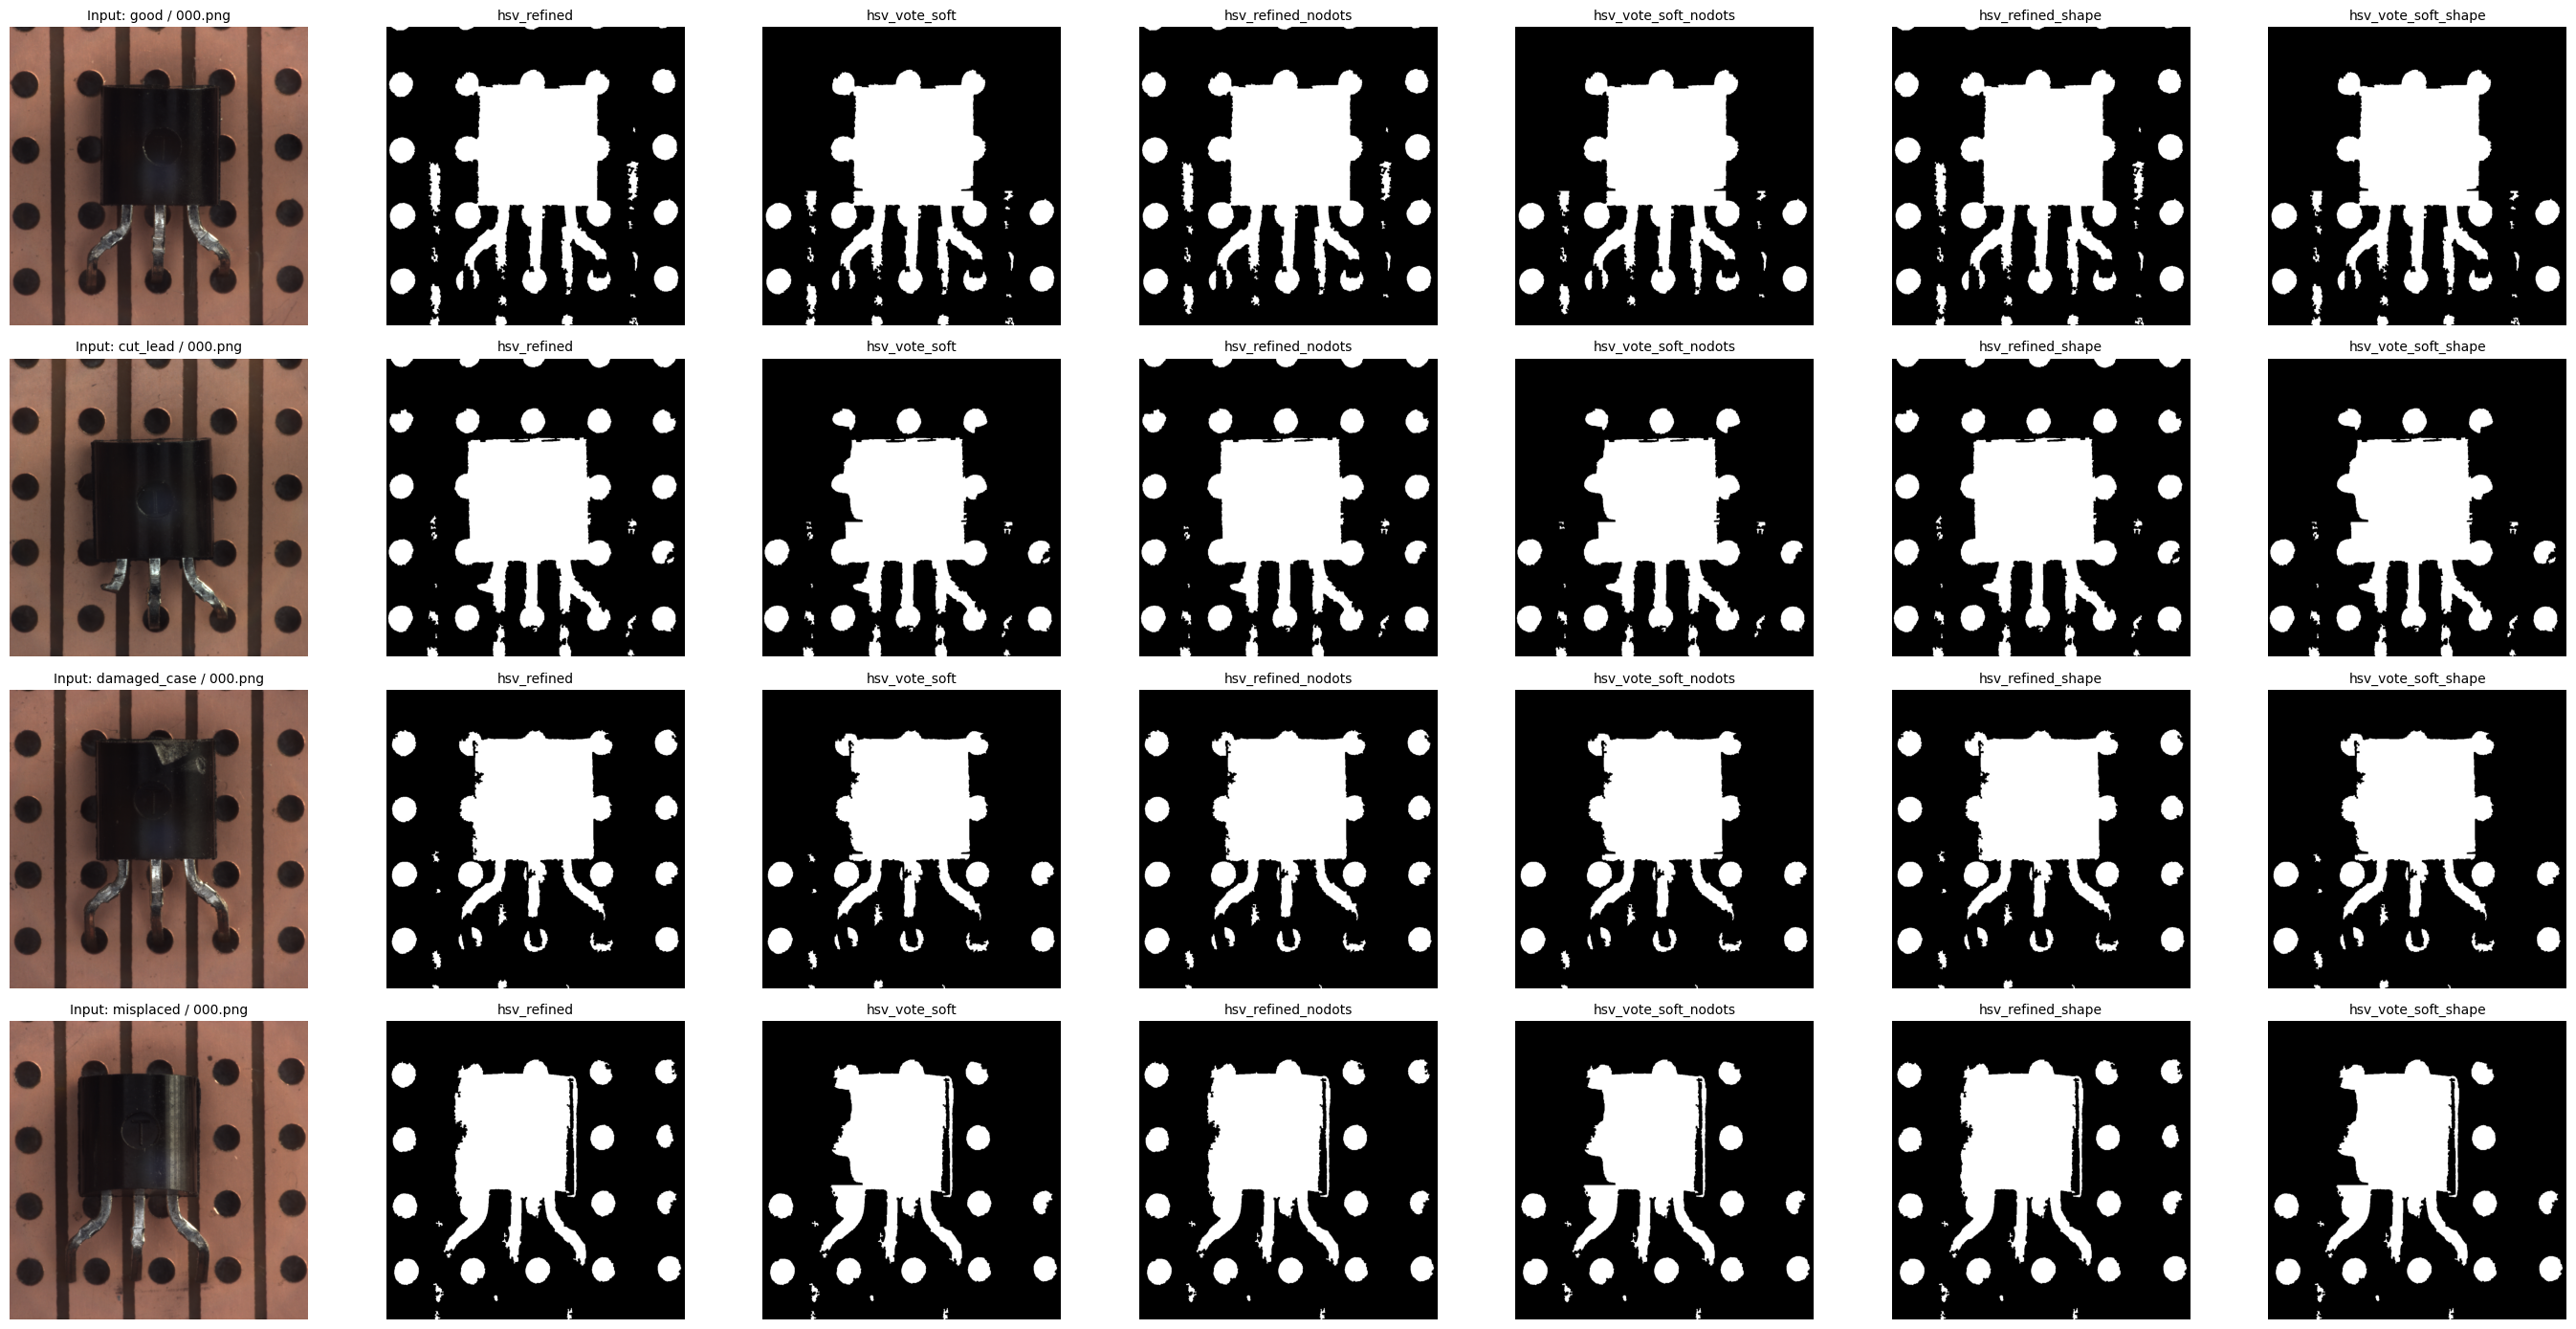

In [27]:
# Wizualne porownanie metod na kilku obrazach
sample_plan = [('good', 0), ('cut_lead', 0), ('damaged_case', 0), ('misplaced', 0)]
samples = []
for cls_name, idx in sample_plan:
    files = sorted((TEST_DIR / cls_name).glob('*.png'))
    if files:
        samples.append((cls_name, files[min(idx, len(files) - 1)]))

rows = len(samples)
cols = 1 + len(METHODS)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
if rows == 1:
    axes = np.array([axes])

method_names = list(METHODS.keys())
for r, (cls_name, p) in enumerate(samples):
    img = load_rgb(p)
    axes[r, 0].imshow(img)
    axes[r, 0].set_title(f"Input: {cls_name} / {p.name}")
    axes[r, 0].axis('off')

    for c, name in enumerate(method_names, start=1):
        m = METHODS[name](img)
        axes[r, c].imshow(m, cmap='gray', vmin=0, vmax=255)
        axes[r, c].set_title(name)
        axes[r, c].axis('off')

plt.tight_layout()
plt.show()

## Co dalej
1. Wybierz metode o najnizszym `border_leak_mean` i sensownym `misplaced_iou_mean`.
2. Potem przechodzimy do eksperymentu `vote-mask` (OR vs glosowanie 60-80%) na `train/good`.
3. Na koniec przenosimy najlepszy wariant do `model.py`.